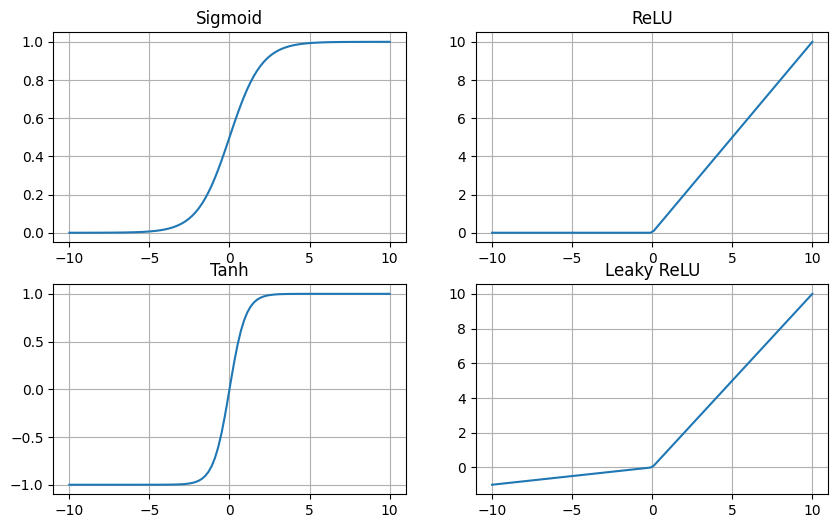

In [38]:
# Q.1) Activation functions
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

funct = {
    'Sigmoid': 1 / (1 + np.exp(-x)),
    'ReLU': np.maximum(0, x),
    'Tanh': np.tanh(x),
    'Leaky ReLU': np.where(x > 0, x, 0.1 * x)
}

# Plot the functions
plt.figure(figsize=(10, 6))
for i, (n, y) in enumerate(funct.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(x, y)
    plt.title(n)
    plt.grid(True)


plt.show()

Accuracy: 0.5
Prediction for '4': -1


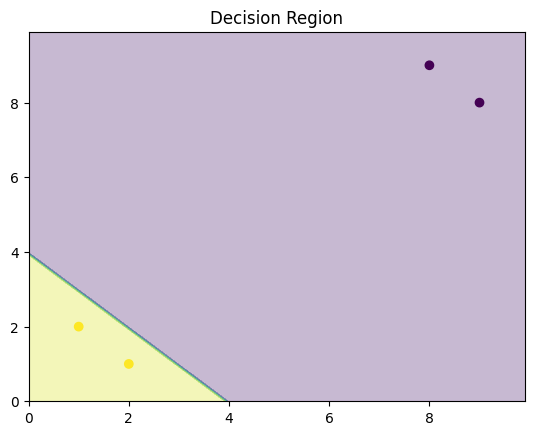

In [39]:
# Q.2) Perceptron neural network
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron


X = np.array([[ord(str(i))] for i in range(10)])  
y = np.array([1 if i % 2 == 0 else -1 for i in range(10)])
model = Perceptron()
model.fit(X, y)

print("Accuracy:", model.score(X, y))
print("Prediction for '4':", model.predict([[ord('4')]])[0])
X2 = np.array([[1, 2], [2, 1], [8, 9], [9, 8]])
y2 = np.array([1, 1, -1, -1])

model2 = Perceptron().fit(X2, y2)

xx, yy = np.meshgrid(np.arange(0, 10, 0.1),
                     np.arange(0, 10, 0.1))

grid = np.array([xx.ravel(), yy.ravel()]).transpose()
Z = model2.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y2)
plt.title("Decision Region")
plt.show()

In [40]:
# Q.3 )  # McCulloch-Pitts Neural Network for ANDNOT

w1 = 1
w2 = -1
theta = 1

inputs = [(0,0), (0,1), (1,0), (1,1)]

print("x1  x2  Output")
print("----------------")

for x1, x2 in inputs:
    net = (w1 * x1) + (w2 * x2)
    if net >= theta:
        output = 1
    else:
        output = 0

    print(x1, " ", x2, "   ", output)

x1  x2  Output
----------------
0   0     0
0   1     0
1   0     1
1   1     0


In [41]:
# Q.4) ANN by forward and back propagation 
import numpy as np
import pandas as pd

data = pd.read_csv("xor_data.csv")
X = data[['x1', 'x2']].values
y = data[['y']].values

np.random.seed(1)
W1 = np.random.rand(2, 2)
W2 = np.random.rand(2, 1)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_d(x):
    return x * (1 - x)

for epoch in range(5000):
    hid = sigmoid(np.dot(X, W1))
    out = sigmoid(np.dot(hid, W2))

    error = y - out

    d_out = error * sigmoid_d(out)
    d_hid = d_out.dot(W2.T) * sigmoid_d(hid)

    W2 += hid.T.dot(d_out)
    W1 += X.T.dot(d_hid)

print("Final Output:\n", out)

Final Output:
 [[0.05652694]
 [0.89514443]
 [0.89514415]
 [0.13920602]]


In [42]:
# Q.5)

import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# FNN
iris = pd.read_csv("Iris [FNN].csv")

target = iris.columns[-1]
X = iris.drop(target, axis=1).values
y = pd.factorize(iris[target])[0]

ffnn = Sequential([
    Dense(8, activation='relu', input_shape=(X.shape[1],)),
    Dense(3, activation='softmax')
])
ffnn.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy')
ffnn.fit(X, y, epochs=20, verbose=0)
ffnn_pred = ffnn.predict(X[:5])

# RNN
imdb = pd.read_csv("IMDB Dataset [RNN].csv")
texts = imdb['review'][:2000]
labels = (imdb['sentiment'][:2000] == 'positive').astype(int)
tok = Tokenizer(num_words=2000)
tok.fit_on_texts(texts)
seq = tok.texts_to_sequences(texts)
pad = pad_sequences(seq, maxlen=100)

rnn = Sequential([
    Embedding(2000, 16, input_length=100),
    SimpleRNN(16),
    Dense(1, activation='sigmoid')
])

rnn.compile(optimizer='adam',
            loss='binary_crossentropy')

rnn.fit(pad, labels, epochs=2, verbose=0)
rnn_pred = rnn.predict(pad[:5])


print("Final Output:\n")
print("FNN:\n", ffnn_pred)
print("\nRNN:\n", rnn_pred)

C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Final Output:

FNN:
 [[0.50327754 0.49177083 0.00495159]
 [0.4532481  0.5403972  0.0063547 ]
 [0.45344925 0.54201853 0.0045322 ]
 [0.42628527 0.56801075 0.00570394]
 [0.4002314  0.59721035 0.00255818]]

RNN:
 [[0.6284287 ]
 [0.6253351 ]
 [0.4246411 ]
 [0.36502522]
 [0.535265  ]]


In [43]:
# Q.6)
import pandas as pd
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

train = pd.read_csv("mnist_train.csv")
test = pd.read_csv("mnist_test.csv")

X_train = train.drop('label', axis=1).values / 255.0
y_train = train['label'].values

X_test = test.drop('label', axis=1).values / 255.0
y_test = test['label'].values
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

model = Sequential([
    Conv2D(16,3,activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=2,verbose=0)
pred = np.argmax(model.predict(X_test[:5]),axis=1)
print("Digit Prediction:", pred)
print("Actual Digits:", y_test[:5])

C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Digit Prediction: [7 2 1 0 4]
Actual Digits: [7 2 1 0 4]


C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Image Classification Accuracy: 0.9804999828338623


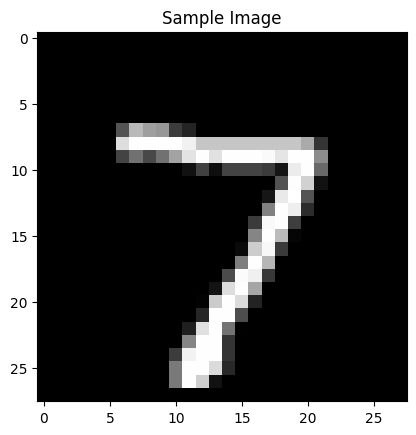

In [44]:
# Q.7)
import pandas as pd
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

train = pd.read_csv("mnist_train.csv")
test = pd.read_csv("mnist_test.csv")

X_train = train.drop('label', axis=1).values / 255.0
y_train = train['label'].values

X_test = test.drop('label', axis=1).values / 255.0
y_test = test['label'].values

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

model = Sequential([
    Conv2D(32,3,activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(32,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=2,verbose=0)
acc = model.evaluate(X_test,y_test,verbose=0)[1]
print("Image Classification Accuracy:", acc)
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Sample Image")
plt.show()

C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Sentiment Accuracy: 0.8675400018692017


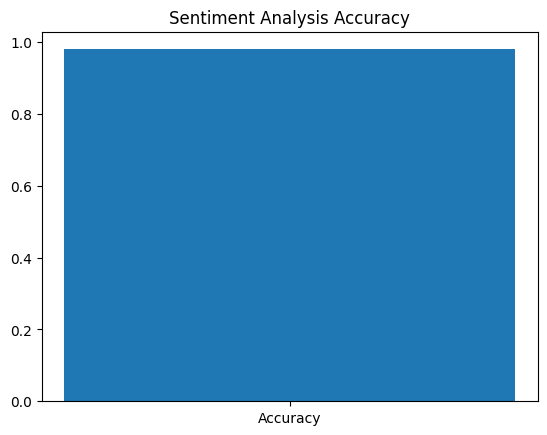

In [45]:
# Q.8) 

import pandas as pd
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

data = pd.read_csv("IMDB Dataset.csv")

texts = data['review']
labels = (data['sentiment'] == 'positive').astype(int)
tok = Tokenizer(num_words=5000)
tok.fit_on_texts(texts)

seq = tok.texts_to_sequences(texts)
X = pad_sequences(seq, maxlen=100)
model = Sequential([
    Embedding(5000, 16, input_length=100),
    SimpleRNN(16),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X, labels, epochs=2, verbose=0)
print("Sentiment Accuracy:", model.evaluate(X, labels, verbose=0)[1])
plt.bar(["Accuracy"], [acc])
plt.title("Sentiment Analysis Accuracy")
plt.show()

C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Forecasted Temperature: 3.07


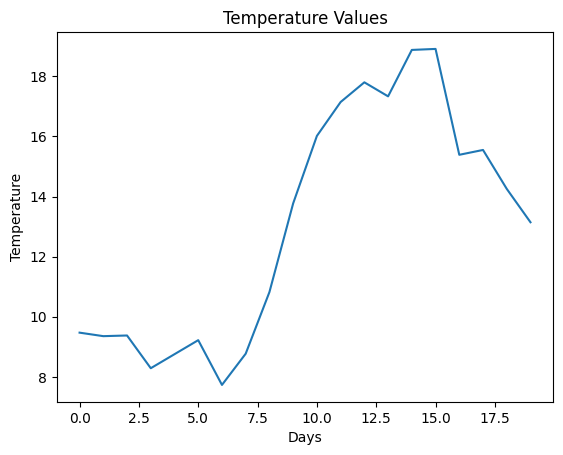

In [46]:
# Q.9) 

import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

data = pd.read_csv("weatherHistory.csv")
temp = data['Temperature (C)'].dropna().values[:200]
X = []
y = []

for i in range(3, len(temp)):
    X.append(temp[i-3:i])
    y.append(temp[i])

X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], 3, 1))
model = Sequential([
    LSTM(20, input_shape=(3,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=10, verbose=0)
new_data = np.array(temp[-3:]).reshape((1,3,1))
pred = model.predict(new_data, verbose=0)
print("Forecasted Temperature:", round(pred[0][0],2))
plt.plot(temp[:20])
plt.title("Temperature Values")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.show()

Reconstruction Error: 0.0101


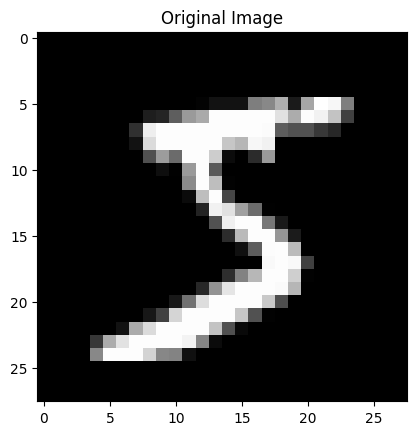

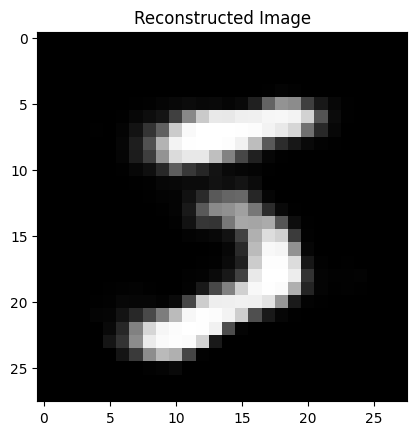

In [47]:
# Q.10) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


data = pd.read_csv("mnist_train.csv")
X = data.drop('label', axis=1).values / 255.0


model = Sequential()
model.add(Dense(32, activation='relu'))
model.add(Dense(784, activation='sigmoid'))
model.compile(optimizer='adam', loss='mse')

model.fit(X, X, epochs=5, verbose=0)
recon = model.predict(X[:100], verbose=0)

error = np.mean((X[:100] - recon) ** 2)
print("Reconstruction Error:", round(error,4))

plt.imshow(X[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.show()

plt.imshow(recon[0].reshape(28,28), cmap='gray')
plt.title("Reconstructed Image")
plt.show()

C:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


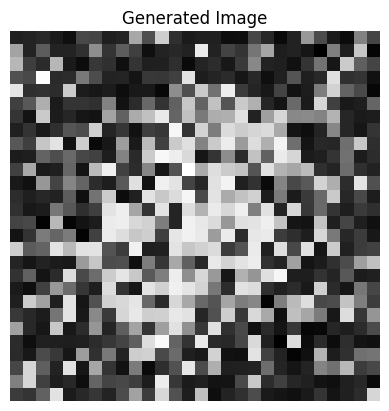

In [48]:
# Q.11) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

data = pd.read_csv("mnist_train.csv")
X = data.drop('label', axis=1).values / 255.0

gen = Sequential([
    Dense(64, activation='relu', input_dim=10),
    Dense(784, activation='sigmoid')
])

disc = Sequential([
    Dense(64, activation='relu', input_dim=784),
    Dense(1, activation='sigmoid')
])

disc.compile(optimizer='adam', loss='binary_crossentropy')
disc.trainable = False
gan = Sequential([gen, disc])
gan.compile(optimizer='adam', loss='binary_crossentropy')
for i in range(50):

    real = X[:16]
    noise = np.random.rand(16,10)
    fake = gen.predict(noise, verbose=0)
    X_train = np.vstack((real, fake))
    y_train = np.vstack((np.ones((16,1)), np.zeros((16,1))))
    disc.trainable = True
    disc.train_on_batch(X_train, y_train)
    disc.trainable = False
    gan.train_on_batch(noise, np.ones((16,1)))

img = gen.predict(np.random.rand(1,10), verbose=0)

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title("Generated Image")
plt.axis("off")
plt.show()